<a href="https://colab.research.google.com/github/suhanibode248/Deep_Learning-/blob/main/cifar10_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
print(torch.cuda.is_available())

True


In [37]:
!pip install torch torchvision matplotlib scikit-learn seaborn

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

In [39]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [40]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

In [41]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [42]:
classes = (
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

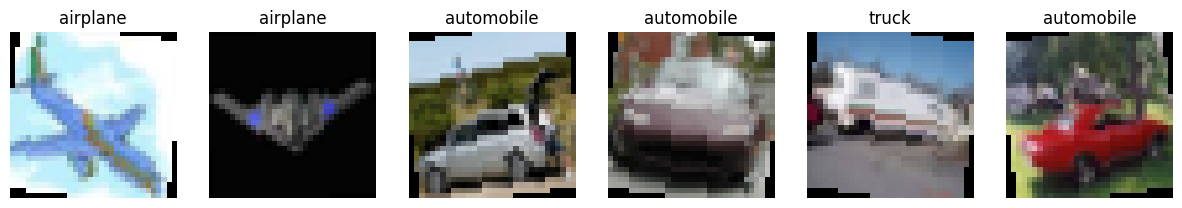

In [43]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(15,5))

for i in range(6):

    img = images[i] / 2 + 0.5
    npimg = img.numpy()

    axes[i].imshow(np.transpose(npimg, (1,2,0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.show()

In [44]:
model = models.resnet18(pretrained=True)

In [45]:
for param in model.parameters():
    param.requires_grad = False

In [46]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 10)

In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


In [48]:
criterion = nn.CrossEntropyLoss()

In [49]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [51]:
train_losses = []
train_accuracies = []

num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch+1}')

    print(f'Loss: {epoch_loss:.4f}')

    print(f'Accuracy: {epoch_accuracy:.2f}%')

Epoch 1
Loss: 1.7192
Accuracy: 39.67%
Epoch 2
Loss: 1.7093
Accuracy: 39.91%
Epoch 3
Loss: 1.7068
Accuracy: 40.05%
Epoch 4
Loss: 1.7067
Accuracy: 40.36%
Epoch 5
Loss: 1.7056
Accuracy: 40.14%


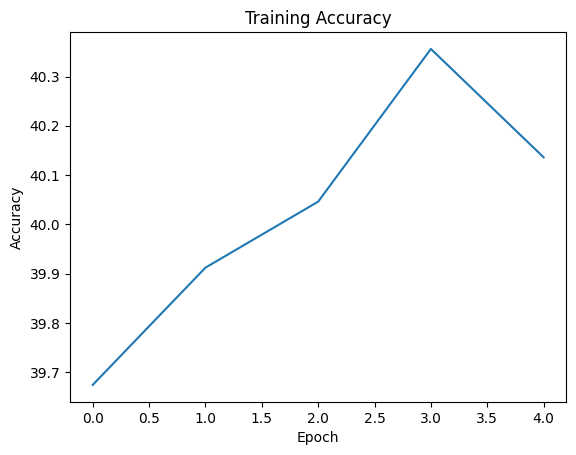

In [52]:
plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

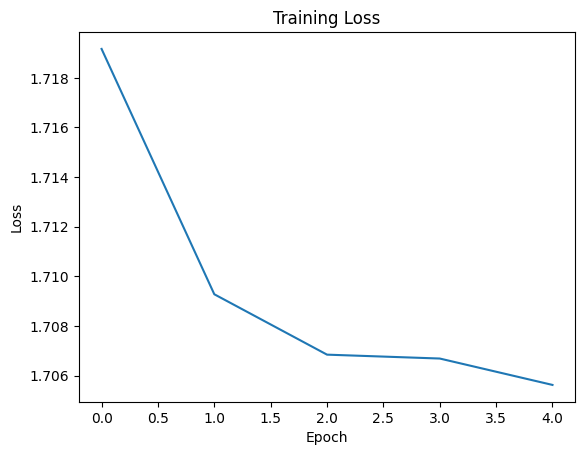

In [53]:
plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [54]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 42.06


In [55]:
torch.save(
    model.state_dict(),
    'cifar10_resnet18.pth'
)

In [56]:
from google.colab import files

files.download('cifar10_resnet18.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>